Nama Anggota:

Ihsan Maulana Prasetia - 24523241

Prima Uziel Nasution - 24523088

# Dimensionality Reduction dengan PCA & t-SNE
## Studi Kasus: Klasifikasi Kualitas Red Wine


## 1. Deskripsi Kasus

### Masalah
Kita memiliki data hasil uji laboratorium **1.599 sampel red wine** (varian *Vinho Verde*, Portugal). Setiap sampel diukur pada **11 properti fisikokimia** (kadar alkohol, keasaman, sulfur dioksida, densitas, pH, dan lain-lain), lalu diberi **skor kualitas 0–10** oleh panelis ahli.

Pertanyaannya: **apakah kualitas wine dapat dijelaskan/dipisahkan berdasarkan profil kimianya?** Dengan 11 fitur sekaligus, kita tidak bisa "melihat" strukturnya secara langsung — mata manusia hanya sanggup mencerna 2–3 dimensi.

### Mengapa Dimensionality Reduction Dibutuhkan
- **Visualisasi:** 11 dimensi mustahil digambar. Kita perlu memampatkannya ke 2D/3D agar pola dan kelompok (cluster) bisa dilihat mata.
- **Redundansi fitur:** beberapa properti kimia saling berkorelasi (mis. `fixed acidity`, `citric acid`, `pH`, `density` bergerak bersama). Reduksi dimensi merangkum informasi yang tumpang tindih ini.
- **Eksplorasi sebelum modeling:** sebelum membangun klasifikator kualitas, kita ingin tahu apakah kelas-kelas kualitas memang membentuk wilayah yang terpisah, atau justru saling tumpang tindih.

Kita akan membandingkan dua teknik: **PCA** (linier, menjaga variansi global) dan **t-SNE** (non-linier, menjaga struktur tetangga lokal).


In [ ]:
# 1. Import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
np.random.seed(42)
print("Library siap.")

Library siap.


## 2. Memuat & Mengeksplorasi Data

Dataset: **Wine Quality (Red)** — Cortez et al., 2009 (UCI Machine Learning Repository).
Sumber file: mirror publik `plotly/datasets`.

In [ ]:
# 2a. Load dataset
df = pd.read_csv("winequality-red.csv")
print("Ukuran dataset:", df.shape)          # (baris, kolom)
print("Jumlah nilai kosong:", df.isnull().sum().sum())
df.head()

Ukuran dataset: (1599, 12)
Jumlah nilai kosong: 0


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
# 2b. Ringkasan statistik singkat
df.describe().T[["mean", "std", "min", "max"]].round(3)

,mean,std,min,max
fixed acidity,8.320,1.741,4.600,15.900
volatile acidity,0.528,0.179,0.120,1.580
citric acid,0.271,0.195,0.000,1.000
residual sugar,2.539,1.410,0.900,15.500
chlorides,0.087,0.047,0.012,0.611
free sulfur dioxide,15.875,10.460,1.000,72.000
total sulfur dioxide,46.468,32.895,6.000,289.000
density,0.997,0.002,0.990,1.004
pH,3.311,0.154,2.740,4.010
sulphates,0.658,0.170,0.330,2.000


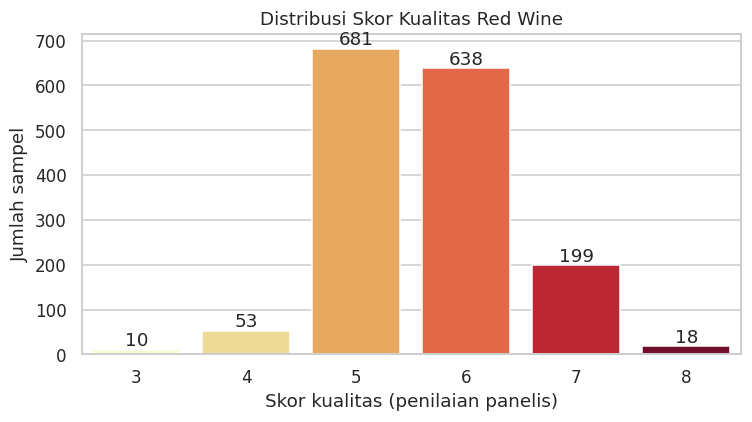

In [ ]:
# 2c. Distribusi skor kualitas
plt.figure(figsize=(7, 4))
ax = sns.countplot(x="quality", data=df, hue="quality",
                   palette="YlOrRd", legend=False)
for c in ax.containers:
    ax.bar_label(c)
plt.title("Distribusi Skor Kualitas Red Wine")
plt.xlabel("Skor kualitas (penilaian panelis)")
plt.ylabel("Jumlah sampel")
plt.tight_layout()
plt.show()

**Catatan:** distribusi sangat tidak seimbang — mayoritas wine berskor 5–6, sedangkan skor ekstrem (3, 4, 8) sangat sedikit. Ini fakta penting: kelas kualitas tidak tersebar merata.

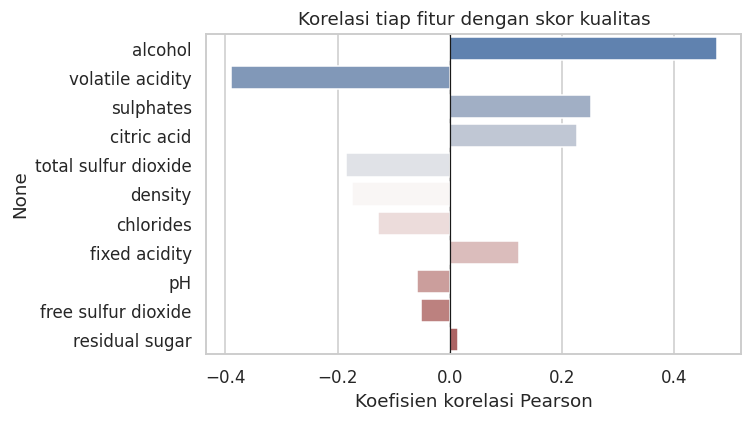

alcohol                 0.476
volatile acidity       -0.391
sulphates               0.251
citric acid             0.226
total sulfur dioxide   -0.185
density                -0.175
chlorides              -0.129
fixed acidity           0.124
pH                     -0.058
free sulfur dioxide    -0.051
residual sugar          0.014
Name: quality, dtype: float64

In [ ]:
# 2d. Fitur mana yang paling berhubungan dengan kualitas?
corr_q = (df.corr(numeric_only=True)["quality"]
            .drop("quality")
            .sort_values(key=abs, ascending=False))

plt.figure(figsize=(7, 4))
sns.barplot(x=corr_q.values, y=corr_q.index, hue=corr_q.index,
            palette="vlag", legend=False)
plt.title("Korelasi tiap fitur dengan skor kualitas")
plt.xlabel("Koefisien korelasi Pearson")
plt.axvline(0, color="k", lw=0.8)
plt.tight_layout()
plt.show()
corr_q.round(3)

**Temuan awal:** kualitas paling berkorelasi positif dengan **alcohol** (+0.48) dan negatif dengan **volatile acidity** (−0.39), lalu **sulphates** (+0.25). Tidak ada satu fitur pun yang berkorelasi sangat kuat — pertanda kualitas ditentukan oleh **kombinasi** banyak faktor, bukan satu variabel dominan.

## 3. Preprocessing

Dua langkah:
1. **Binning kualitas** menjadi 3 kategori agar mudah divisualisasikan sebagai warna: `Low (3–4)`, `Medium (5–6)`, `High (7–8)`.
2. **Standardisasi** (mean 0, std 1). Ini **wajib** sebelum PCA/t-SNE karena kedua metode berbasis jarak/variansi — tanpa scaling, fitur berskala besar seperti `total sulfur dioxide` (puluhan–ratusan) akan mendominasi fitur berskala kecil seperti `density` (~0.99).

In [ ]:
# 3a. Binning kualitas -> 3 kategori
def to_category(v):
    if v <= 4:  return "Low (3-4)"
    if v <= 6:  return "Medium (5-6)"
    return "High (7-8)"

df["quality_cat"] = df["quality"].apply(to_category)
cat_order = ["Low (3-4)", "Medium (5-6)", "High (7-8)"]

feature_cols = [c for c in df.columns if c not in ("quality", "quality_cat")]
X = df[feature_cols].values
y = df["quality_cat"].values

print("Jumlah fitur:", len(feature_cols))
print(df["quality_cat"].value_counts()[cat_order])

Jumlah fitur: 11
quality_cat
Low (3-4)         63
Medium (5-6)    1319
High (7-8)       217
Name: count, dtype: int64


In [ ]:
# 3b. Standardisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Sebelum scaling  -> mean fitur pertama: %.2f, std: %.2f" % (X[:,0].mean(), X[:,0].std()))
print("Sesudah scaling  -> mean fitur pertama: %.2f, std: %.2f" % (X_scaled[:,0].mean(), X_scaled[:,0].std()))

Sebelum scaling  -> mean fitur pertama: 8.32, std: 1.74
Sesudah scaling  -> mean fitur pertama: 0.00, std: 1.00


## 4. PCA (Principal Component Analysis)

PCA mencari **arah (komponen) dengan variansi terbesar** dalam data, lalu memproyeksikan data ke komponen-komponen tersebut. Bersifat **linier**, **deterministik**, dan komponennya dapat diinterpretasikan.

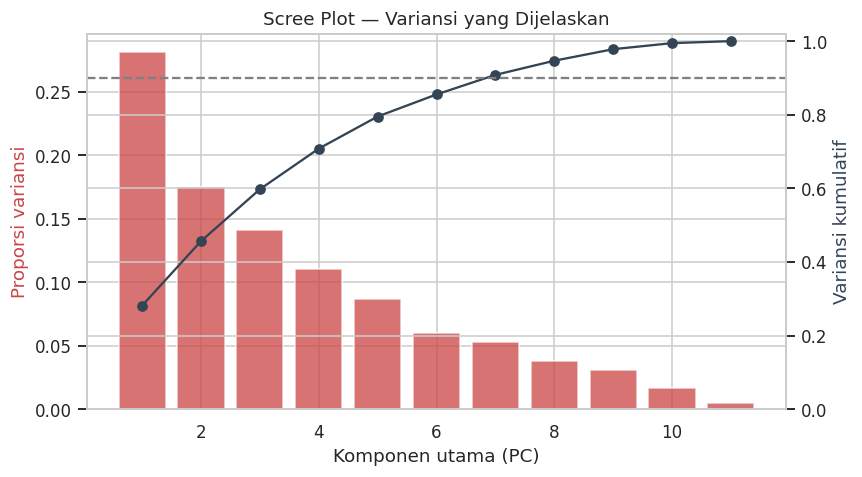

Variansi PC1..PC3: [0.282 0.175 0.141]
PC1+PC2      = 45.7%
PC1+PC2+PC3  = 59.8%
Komponen untuk >=90%% variansi: 7


In [ ]:
# 4a. PCA penuh -> berapa variansi yang ditangkap tiap komponen?
pca_full = PCA().fit(X_scaled)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.bar(range(1, len(evr)+1), evr, color="#c44", alpha=0.75, label="Per komponen")
ax1.set_xlabel("Komponen utama (PC)")
ax1.set_ylabel("Proporsi variansi", color="#c44")
ax2 = ax1.twinx()
ax2.plot(range(1, len(cum)+1), cum, "o-", color="#345", label="Kumulatif")
ax2.axhline(0.9, ls="--", color="gray")
ax2.set_ylabel("Variansi kumulatif", color="#345")
ax2.set_ylim(0, 1.02)
plt.title("Scree Plot — Variansi yang Dijelaskan")
plt.tight_layout()
plt.show()

print("Variansi PC1..PC3:", np.round(evr[:3], 3))
print("PC1+PC2      = %.1f%%" % (evr[:2].sum()*100))
print("PC1+PC2+PC3  = %.1f%%" % (evr[:3].sum()*100))
print("Komponen untuk >=90%% variansi:", int(np.argmax(cum >= 0.9)) + 1)

**Interpretasi scree plot:** PC1+PC2 hanya menangkap **~46%** variansi, dan butuh **7 komponen** untuk mencapai 90%. Artinya informasi tersebar cukup merata di banyak arah — proyeksi 2D pasti kehilangan sebagian besar informasi. Ini ekspektasi realistis untuk data kimia yang kompleks.

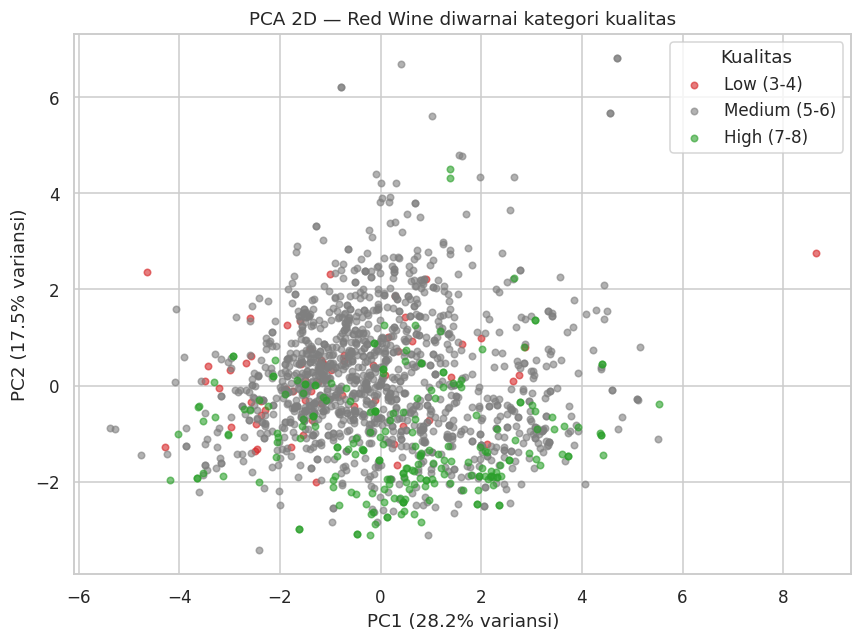

In [ ]:
# 4b. PCA -> 2D dan visualisasi
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

palette = {"Low (3-4)": "#d62728", "Medium (5-6)": "#7f7f7f", "High (7-8)": "#2ca02c"}
plt.figure(figsize=(8, 6))
for cat in cat_order:
    m = y == cat
    plt.scatter(X_pca2[m, 0], X_pca2[m, 1], s=18, alpha=0.6,
                label=cat, color=palette[cat])
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variansi)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variansi)")
plt.title("PCA 2D — Red Wine diwarnai kategori kualitas")
plt.legend(title="Kualitas")
plt.tight_layout()
plt.show()

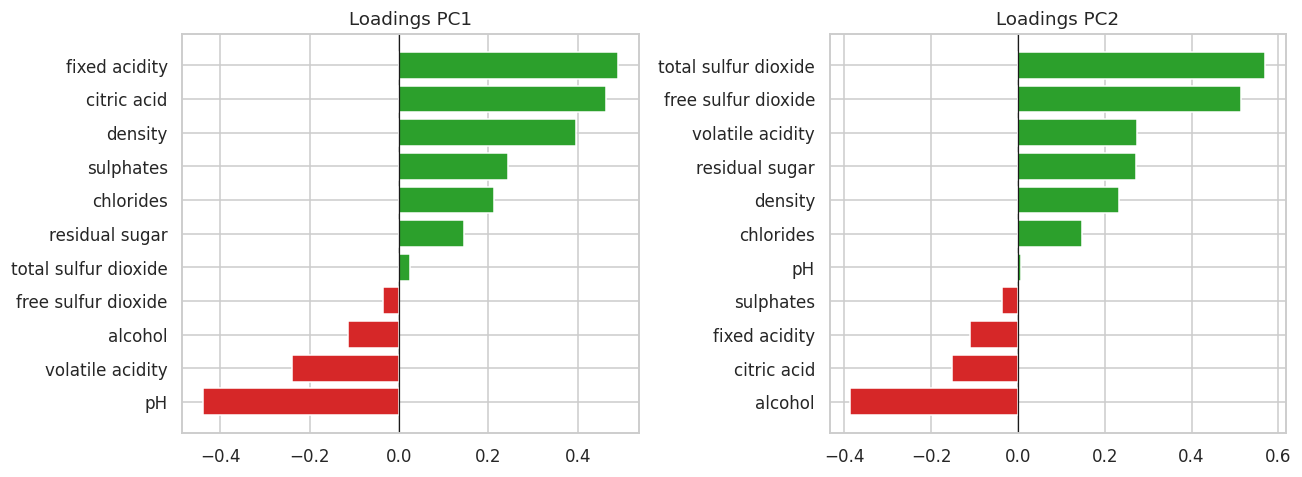

,PC1,PC2
fixed acidity,0.489,-0.111
volatile acidity,-0.239,0.275
citric acid,0.464,-0.152
residual sugar,0.146,0.272
chlorides,0.212,0.148
free sulfur dioxide,-0.036,0.514
total sulfur dioxide,0.024,0.569
density,0.395,0.234
pH,-0.439,0.007
sulphates,0.243,-0.038


In [ ]:
# 4c. Loadings: fitur apa yang membentuk PC1 & PC2?
loadings = pd.DataFrame(pca2.components_.T, index=feature_cols, columns=["PC1", "PC2"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, pc in zip(axes, ["PC1", "PC2"]):
    s = loadings[pc].sort_values()
    ax.barh(s.index, s.values, color=np.where(s.values >= 0, "#2ca02c", "#d62728"))
    ax.set_title(f"Loadings {pc}")
    ax.axvline(0, color="k", lw=0.8)
plt.tight_layout()
plt.show()
loadings.round(3)

**Interpretasi PCA 2D:**
- **PC1** didominasi oleh `fixed acidity`, `citric acid`, `pH`, dan `density` — ini adalah **sumbu "struktur keasaman"** wine.
- **PC2** didominasi oleh `free/total sulfur dioxide` dan `alcohol` — semacam **sumbu "pengawetan & kadar alkohol"**.
- **Poin penting:** dua fitur yang paling berkorelasi dengan kualitas (`alcohol`, `volatile acidity`) *bukan* penyusun utama PC1. Karena itu, arah variansi terbesar (yang ditangkap PCA) **tidak sejajar** dengan arah yang memisahkan kualitas. Akibatnya, di scatter PCA titik `Low`/`Medium`/`High` **saling tumpang tindih** dan tidak membentuk cluster terpisah.

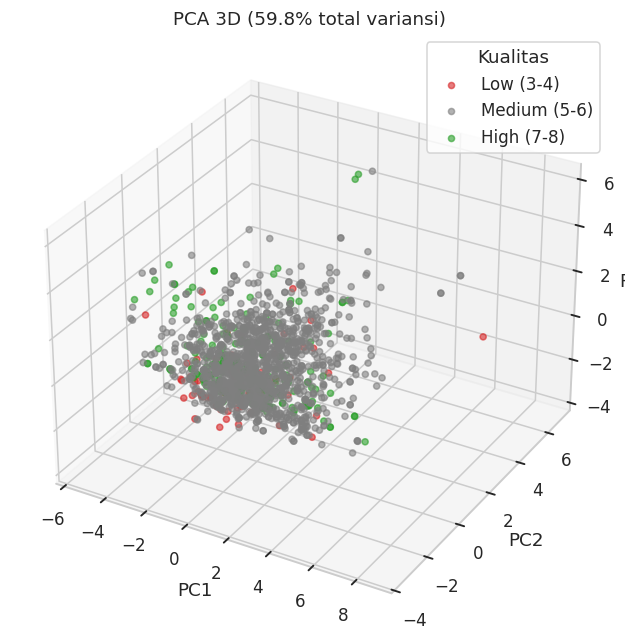

In [ ]:
# 4d. PCA -> 3D (opsional, memberi sedikit informasi tambahan)
pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
for cat in cat_order:
    m = y == cat
    ax.scatter(X_pca3[m, 0], X_pca3[m, 1], X_pca3[m, 2],
               s=16, alpha=0.6, label=cat, color=palette[cat])
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
ax.set_title(f"PCA 3D ({pca3.explained_variance_ratio_.sum()*100:.1f}% total variansi)")
ax.legend(title="Kualitas")
plt.tight_layout()
plt.show()

## 5. t-SNE (t-Distributed Stochastic Neighbor Embedding)

t-SNE adalah teknik **non-linier** yang berfokus menjaga **struktur tetangga lokal**: titik yang berdekatan di ruang 11-dimensi diusahakan tetap berdekatan di 2D. Sangat baik untuk **mengungkap cluster** yang tak terlihat oleh proyeksi linier.

Hyperparameter utama:
- `perplexity` (~30): menyeimbangkan perhatian pada tetangga dekat vs jauh.
- `init="pca"`: inisialisasi dari PCA agar hasil lebih stabil & reprodusibel.

> Catatan: sumbu t-SNE **tidak punya makna kuantitatif** (tidak ada "variansi %"). Yang bermakna hanya *kedekatan* antar titik. t-SNE untuk **eksplorasi visual**, bukan sebagai fitur untuk modeling.

In [ ]:
# 5a. t-SNE -> 2D  (butuh beberapa puluh detik untuk 1599 sampel)
tsne = TSNE(n_components=2, perplexity=30, init="pca",
            learning_rate="auto", max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
print("Bentuk hasil t-SNE:", X_tsne.shape)

Bentuk hasil t-SNE: (1599, 2)


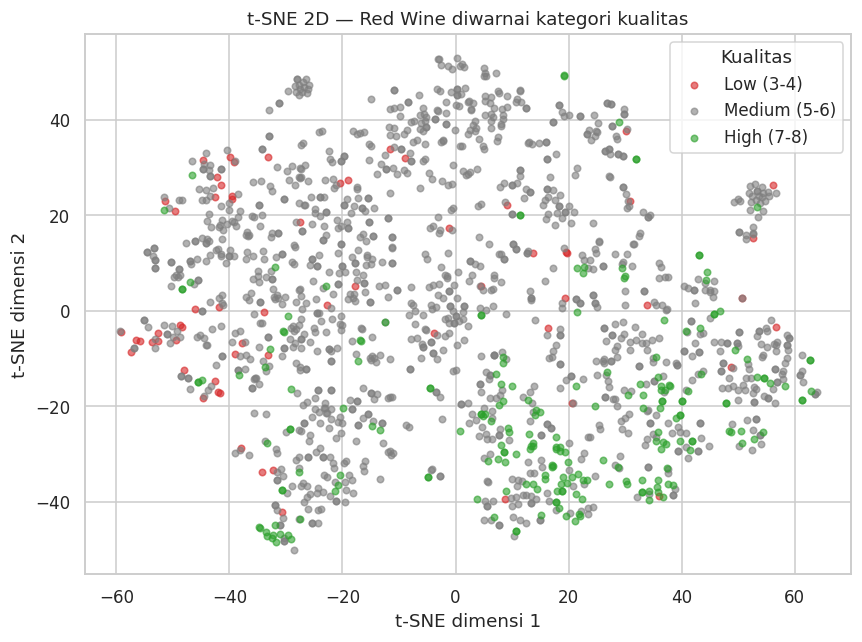

In [ ]:
# 5b. Visualisasi t-SNE 2D
plt.figure(figsize=(8, 6))
for cat in cat_order:
    m = y == cat
    plt.scatter(X_tsne[m, 0], X_tsne[m, 1], s=18, alpha=0.6,
                label=cat, color=palette[cat])
plt.xlabel("t-SNE dimensi 1")
plt.ylabel("t-SNE dimensi 2")
plt.title("t-SNE 2D — Red Wine diwarnai kategori kualitas")
plt.legend(title="Kualitas")
plt.tight_layout()
plt.show()

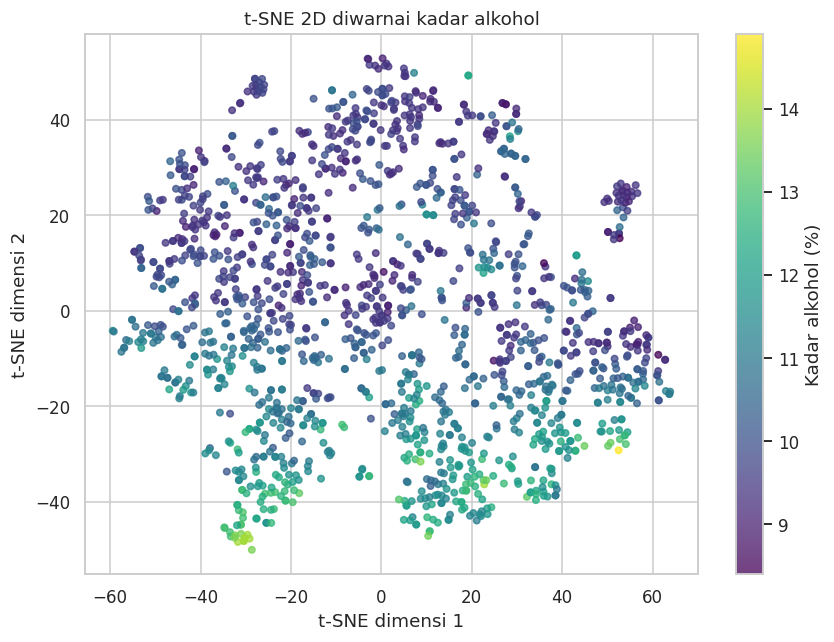

In [ ]:
# 5c. Pembanding: t-SNE diwarnai kadar alkohol (fitur paling terkait kualitas)
plt.figure(figsize=(8, 6))
sc = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df["alcohol"],
                 cmap="viridis", s=18, alpha=0.75)
plt.colorbar(sc, label="Kadar alkohol (%)")
plt.xlabel("t-SNE dimensi 1"); plt.ylabel("t-SNE dimensi 2")
plt.title("t-SNE 2D diwarnai kadar alkohol")
plt.tight_layout()
plt.show()

**Interpretasi t-SNE:**
- t-SNE memunculkan beberapa **gumpalan (blob) lokal** yang lebih rapi dibanding PCA — ini struktur non-linier yang tak tertangkap proyeksi linier.
- Namun, saat diwarnai kategori kualitas, gumpalan-gumpalan itu **tetap didominasi kelas `Medium`** dan tidak terpisah bersih per kualitas. Wine `High` cenderung menempati tepi tertentu, bukan cluster eksklusif.
- Plot yang diwarnai **kadar alkohol** menunjukkan gradien yang lebih jelas: wilayah t-SNE tertentu memang beralkohol lebih tinggi — konsisten dengan alcohol sebagai penanda kualitas terkuat. Ini menegaskan bahwa kualitas berkaitan dengan kimia, tetapi sebagai **gradien kontinu**, bukan kelompok terpisah.

## 6. Analisis: PCA vs t-SNE

| Aspek | PCA | t-SNE |
|---|---|---|
| Jenis | Linier | Non-linier |
| Yang dijaga | Variansi **global** | Struktur **tetangga lokal** |
| Sumbu | Bermakna (variansi %, loadings) | Tidak bermakna kuantitatif |
| Determinisme | Deterministik | Stokastik (bergantung seed/perplexity) |
| Data baru | Bisa diproyeksikan (`transform`) | Tidak (harus fit ulang) |
| Kecepatan | Cepat | Lambat pada data besar |
| Kegunaan utama | Preprocessing / kompresi fitur | Eksplorasi & visualisasi cluster |

### Perbedaan hasil pada kasus ini
- **PCA** memampatkan 11 fitur menjadi sumbu variansi terbesar, tetapi karena arah variansi tak sejajar dengan arah kualitas, kelas kualitas **tumpang tindih** dan sulit dibedakan visual. Kelebihannya: kita **paham** apa yang diwakili tiap sumbu (via loadings).
- **t-SNE** mengungkap **gumpalan lokal** yang lebih terstruktur dan gradien alkohol yang lebih jelas, sehingga secara **visual lebih informatif** untuk melihat kemiripan antar wine. Kekurangannya: sumbu tak bisa ditafsirkan dan hasilnya tak reprodusibel untuk data baru.

### Metode mana yang lebih sesuai?
Tergantung tujuan:
- **Untuk eksplorasi & visualisasi cluster (tujuan utama tugas ini) → t-SNE lebih sesuai**, karena menampilkan struktur lokal dan gradien yang tidak terlihat pada PCA.
- **Untuk preprocessing sebelum modeling klasifikasi kualitas → PCA lebih sesuai**, karena deterministik, cepat, sumbunya bermakna, dan mampu memproyeksikan data uji baru dengan `transform`.

### Kesimpulan besar
Baik PCA maupun t-SNE menunjukkan hal yang konsisten: **kualitas red wine tidak membentuk kelas yang terpisah bersih di ruang fitur kimianya.** Kualitas adalah **kontinum** yang dipengaruhi kombinasi fitur (terutama alcohol dan volatile acidity), bukan sekumpulan cluster diskret. Temuan ini penting sebelum modeling: sebuah klasifikator kualitas kemungkinan akan kesulitan pada batas antar-kelas, dan pendekatan **regresi** (memprediksi skor kontinu) mungkin lebih tepat daripada klasifikasi keras.
